# Linear heat conduction problem with same material, with full order and reduced order simulations.

## Environment Setup

### Directories

In [1]:
import sys
from pathlib import Path
import importlib

# -----------------------------------------------------------------------------
# Project-root auto-detection script
# Ensures the top-level directory (containing 'src/' and 'tests/')
# is on Python's import path, allowing modules to be imported consistently
# regardless of the current working directory (e.g., in notebooks).
# -----------------------------------------------------------------------------

# 1) Start from the current working directory (or notebook location)
notebook_path = Path().resolve()
linear_dir = notebook_path.parent     # .../linear
# 2) Traverse upward through parent directories to find the project root
for parent in notebook_path.parents:
    # Check for indicators of the project's root structure
    if (parent / "src").exists() and (parent / "tests").exists():
        project_root = parent
        break
else:
    # If loop completes without break, no valid root was found
    raise RuntimeError(
        "Could not find project root containing 'src' and 'tests'"
    )

# 3) Prepend the detected root to sys.path to prioritize local modules
sys.path.insert(0, str(project_root))

if str(linear_dir) not in sys.path:
    sys.path.insert(0, str(linear_dir))
    
# 4) Confirm successful addition (optional print for debugging)
print("Project root added to sys.path:", project_root)

Project root added to sys.path: /Users/syedabidi/Documents/GitHub/scikit-rom


### Standard Imports

In [2]:
#Import class and other important functions
import src.skrom.problem_classes.master_class_static as master
from src.skrom.utils.imports import *
from src.skrom.rom.rom_utils import *
from src.skrom.utils.reduced_basis.svd import svd_mode_selector
from src.skrom.rom.rom_error_est import *
from src.skrom.utils.visualization.color_palette import set_color_palette
from src.skrom.utils.visualization.generate_vtk import *
importlib.import_module("problem_4.problem_def")   # this runs @register_problem

<module 'problem_4.problem_def' from '/Users/syedabidi/Documents/GitHub/scikit-rom/tests/heat_transfer/static/linear/problem_4/problem_def.py'>

### Plot Properties

In [3]:
# # Define a custom color palette with 19 distinct colors
set_color_palette();

## Full Order Simulation

In [4]:
# Control flag for expensive simulation generation
generate = True

# Conditional execution block for simulation data generation
if generate:
    
    # Create an instance of the linear heat conduction simulation
    sim =  master.fom_simulation()
    sim.run_simulation()



Snap 1/64 params=[5.02021261]

Snap 2/64 params=[1.9700064]
Snap 3/64 params=[0.98250048]
Snap 4/64 params=[4.3764915]
Snap 5/64 params=[3.58757857]
Snap 6/64 params=[0.5479427]
Snap 7/64 params=[2.46119374]
Snap 8/64 params=[5.84309885]
Snap 9/64 params=[5.60236948]
Snap 10/64 params=[2.84350296]
Snap 11/64 params=[0.74903227]
Snap 12/64 params=[3.16561297]
Snap 13/64 params=[4.16974089]
Snap 14/64 params=[1.42145576]
Snap 15/64 params=[2.22773115]
Snap 16/64 params=[4.632237]
Snap 17/64 params=[4.86539998]
Snap 18/64 params=[2.17578547]
Snap 19/64 params=[1.55118256]
Snap 20/64 params=[3.8587743]
Snap 21/64 params=[3.38741394]
Snap 22/64 params=[0.70846933]
Snap 23/64 params=[2.98452538]
Snap 24/64 params=[5.28013078]
Snap 25/64 params=[5.80404423]
Snap 26/64 params=[2.68148848]
Snap 27/64 params=[0.22420189]
Snap 28/64 params=[3.7301024]
Snap 29/64 params=[4.32605275]
Snap 30/64 params=[1.21415583]
Snap 31/64 params=[1.6575391]
Snap 32/64 params=[5.15144219]
Snap 33/64 params=[3.11

### Load Simulation Data

In [5]:
#Load the ROM_data
current_dir = Path().resolve()
rom_dir = current_dir / "ROM_data"
fos_solutions, sim_data = load_rom_data(self=None, rom_data_dir=rom_dir)

[load_rom_data] loaded from /Users/syedabidi/Documents/GitHub/scikit-rom/tests/heat_transfer/static/linear/problem_4/ROM_data


## Data Generation

### Generate training solution dataset

In [6]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list = np.asarray(sim_data['param_list'])

# Load non-linear solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
LS = np.asarray(fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = sim_data['train_mask'], sim_data['test_mask']

# Apply masks to filter non-linear solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
LS_train = LS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
LS_test = LS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap, _ = np.shape(LS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available


64


### Training Solution Snapshots

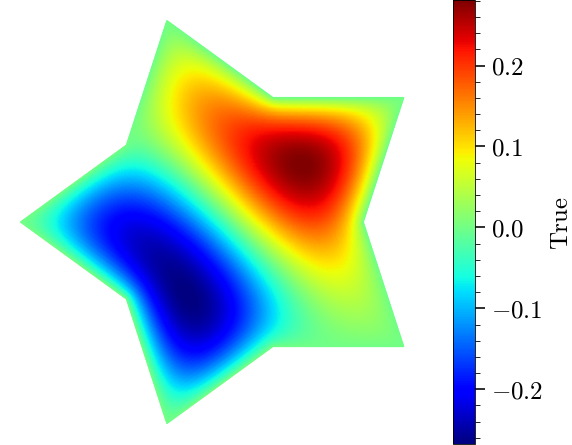

In [7]:
visualize2D(LS_test[0],sim_data['basis'].item())

### Mean Subtraction

In [8]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
LS_train_mean = np.mean(LS_train,axis = 0)
# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
LS_train_ms = LS_train - LS_train_mean
#We will use SVD on the mean subtracted matrix data

### Performing SVD on training snapshots

Number of modes selected: 2


Text(0.5, 0, 'POD modes ($k$)')

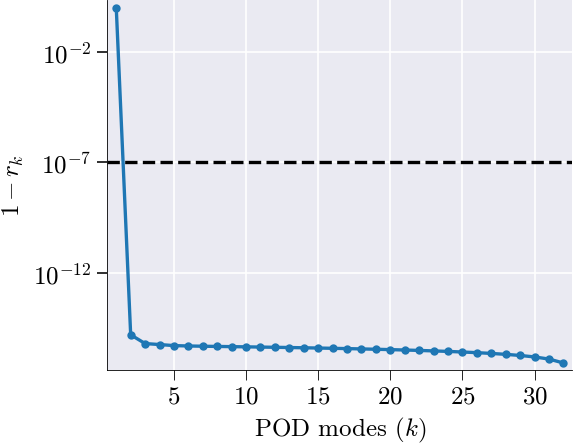

In [9]:
# Configure plot styling for POD analysis visualization
plt.rcParams['lines.markersize'] = 6      # Set marker size for data points
plt.rcParams['lines.linewidth'] = 2.0     # Set line thickness for better visibility

# Perform Singular Value Decomposition (SVD) for POD mode selection
# SVD decomposes the mean-centered training data to find optimal basis functions
n_sel, U = svd_mode_selector(LS_train_ms,    # Input: mean-centered training snapshots
                            tolerance=1e-7,    # Convergence criterion for mode selection
                            modes=True)        # Return both number of modes and basis vectors


# Extract the selected POD basis vectors (spatial modes)
# V_sel contains the first n_sel most energetic POD modes
# Shape: [N_dof, n_sel] - each column is a spatial basis function
V_sel = U[:, :n_sel]  # This will be passed to the ROM simulation function

# Set axis labels for the POD energy plot (generated by svd_mode_selector)
plt.ylabel('$1-r_{k}$')           # Energy not captured by first k modes
plt.xlabel('POD modes ($k$)')     # Number of POD modes retained

## ROM Simulation

In [10]:
# Initialize the reduced-order model (ROM) simulation with affine decomposition for speed-up
#   V_sel : precomputed basis matrix (e.g., selected POD modes)
rom = master.rom_simulation(V_sel=V_sel)

[load_rom_data] loaded from /Users/syedabidi/Documents/GitHub/scikit-rom/tests/heat_transfer/static/linear/problem_4/ROM_data


In [11]:
# Run the reduced-order model (ROM) simulation.
# rom object will contain the NLS rom simulation solutions and other simulation aspects required by ROM such as the param_list etc.
rom.run_rom_simulation();

Snap 1/64 params=[3.11132794]

Snap 2/64 params=[0.97492384]
Snap 3/64 params=[2.32310872]
Snap 4/64 params=[5.99985049]
Snap 5/64 params=[4.75741445]
Snap 6/64 params=[2.63380121]
Snap 7/64 params=[0.67418495]
Snap 8/64 params=[4.33813526]
Snap 9/64 params=[4.09991364]
Snap 10/64 params=[0.52654101]
Snap 11/64 params=[2.78068874]
Snap 12/64 params=[4.99497369]
Snap 13/64 params=[5.39908155]
Snap 14/64 params=[1.8130121]
Snap 15/64 params=[1.48435808]
Snap 16/64 params=[3.71134047]
Snap 17/64 params=[3.64035139]
Snap 18/64 params=[1.41374545]
Snap 19/64 params=[1.87831471]
Snap 20/64 params=[5.46405257]
Snap 21/64 params=[5.24117241]
Snap 22/64 params=[3.0272633]
Snap 23/64 params=[0.27465642]
Snap 24/64 params=[3.84769686]
Snap 25/64 params=[4.44841878]
Snap 26/64 params=[0.78480006]
Snap 27/64 params=[2.51787607]
Snap 28/64 params=[4.64111287]
Snap 29/64 params=[5.70232121]
Snap 30/64 params=[2.02591163]
Snap 31/64 params=[1.2668109]
Snap 32/64 params=[3.40283916]


In [12]:
#Assign values for the statistics
LS_rom = np.asarray(rom.rom_solutions)
ROM_speed_up = rom.speed_up
ROM_speed_up=ROM_speed_up[1:]
ROM_relative_error = rom.rom_error

### ROM solution vs. Full order solution performance statistics 

ROM Accuracy Report

Global Errors:
L2 Error:                 4.5351e-13
Relative L2 Error:        3.4929e-15
L∞ Error:                 2.7756e-15
Relative L∞ Error:        5.1299e-15
RMSE:                     5.5586e-16
MAE:                      3.1892e-16

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             0.0000e+00
95th Percentile Error:    1.3323e-15

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 2.8289e-15
Max Rel L2 Error over time/parameter: 6.7283e-15
Min Rel L2 Error over time/parameter: 2.7684e-16
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

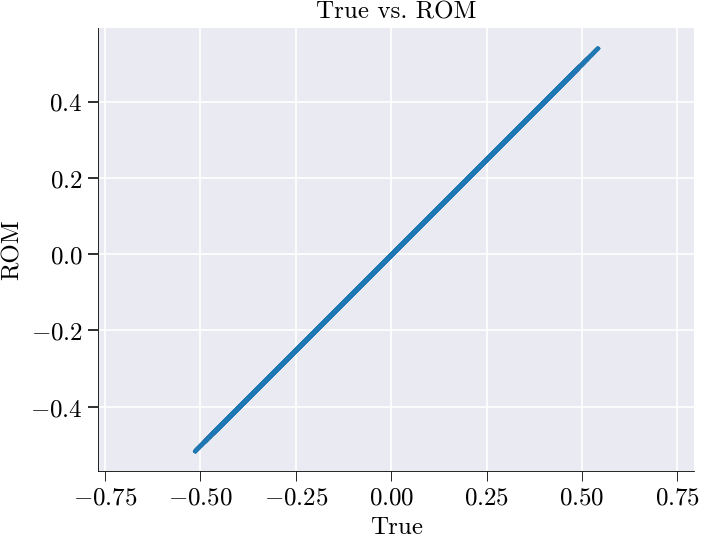

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


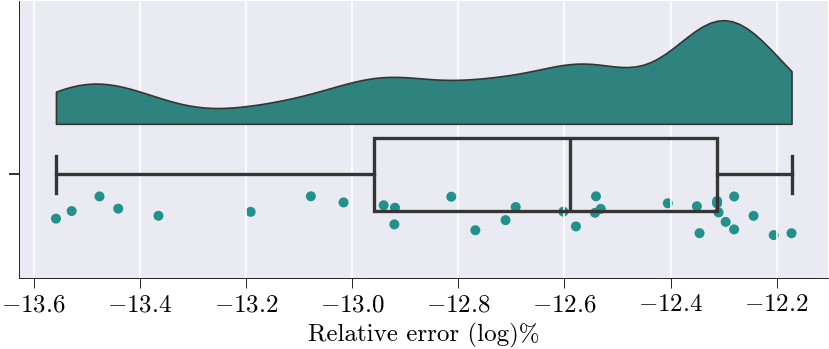

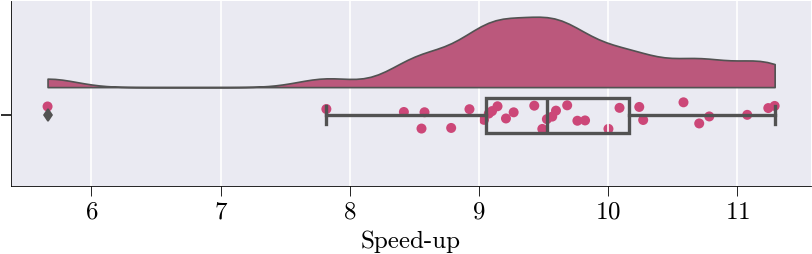

In [13]:
# --- Hyper-reduced ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
matrix = compute_rom_error_metrics_flat(LS_test, LS_rom)

# Produce a text-based report summarizing these hyper-ROM error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
plot_rom_error_diagnostics_flat(
    LS_test,                   # full-order (true) solution snapshots
    LS_rom,              # hyper-ROM-generated solution snapshots
    ROM_relative_error,   # precomputed relative error of the hyper-ROM
    ROM_speed_up,         # precomputed speed-up factor of the hyper-ROM
    sim_axis=['True', 'ROM'], 
    metrics=matrix              # the matrix of error metrics just computed
)
